# **ANALÍTICA APLICADA EN LA GESTION FINANCIERA**
# **LAURA VANESSA ALARCÓN ALBA**
# **Modelo de abandono de usuarios bancarios**

In [ ]:
# Importación de librerías
import matplotlib.pyplot as plt
import seaborn as sb

import numpy as np
import random
import pandas as pd

np.random.seed(42)
random.seed(42)

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier

print("Librerías oficiales importadas con éxito.")


Librerías oficiales importadas con éxito.


In [ ]:
from google.colab import files
uploaded = files.upload()

nombre_archivo = list(uploaded.keys())[0]

bank = pd.read_csv(nombre_archivo, sep=';')
print(f"\n[OK] Dataset cargado correctamente.")
print(f"Dimensiones del dataset: {bank.shape[0]} filas y {bank.shape[1]} columnas.")
bank.head()

Saving bank-full.csv to bank-full.csv

[OK] Dataset cargado correctamente.
Dimensiones del dataset: 45211 filas y 17 columnas.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# **ANÁLISIS EXPLORATORIO**



--- Información de las Variables Bancarias ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

--- Distribución de la Variable Objetivo 'y' -

/tmp/ipykernel_3599/1763441305.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='y', data=bank, palette='Set2')


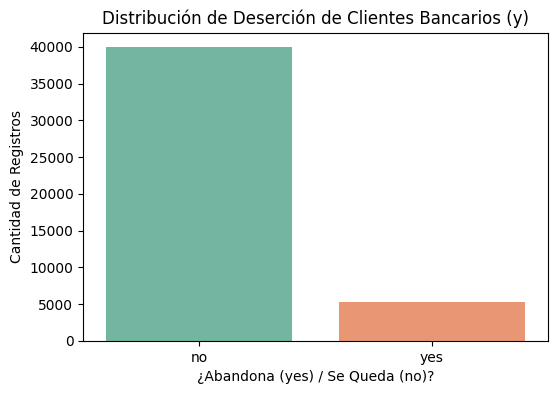

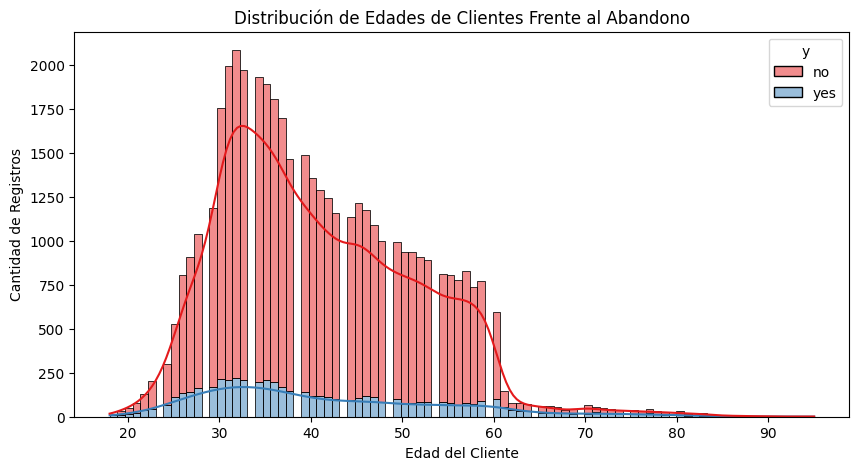


--- Estadísticas Descriptivas Cuantitativas ---
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.0

In [ ]:
# 1. Estructura general de las variables bancarias
print("--- Información de las Variables Bancarias ---")
print(bank.info())

# 2. Distribución y balanceo del abandono (variable y)
print("\n--- Distribución de la Variable Objetivo 'y' ---")
print(bank['y'].value_counts(normalize=True) * 100)

# 3. Gráfico de barras de la deserción de clientes
plt.figure(figsize=(6,4))
sb.countplot(x='y', data=bank, palette='Set2')
plt.title('Distribución de Deserción de Clientes Bancarios (y)')
plt.xlabel('¿Abandona (yes) / Se Queda (no)?')
plt.ylabel('Cantidad de Registros')
plt.show()

# 4. Histograma para analizar el impacto de la edad en el abandono
plt.figure(figsize=(10,5))
sb.histplot(data=bank, x='age', hue='y', multiple='stack', kde=True, palette='Set1')
plt.title('Distribución de Edades de Clientes Frente al Abandono')
plt.xlabel('Edad del Cliente')
plt.ylabel('Cantidad de Registros')
plt.show()

# 5. Estadísticas descriptivas de las variables numéricas primarias
print("\n--- Estadísticas Descriptivas Cuantitativas ---")
print(bank.describe())

# **PREPARACIÓN DE LOS DATOS**

In [ ]:
# 1. Cambiar características de texto 'yes'/'no' a numéricas '1'/'0'
for f in ['default', 'housing', 'loan', 'y']:
    bank[f] = pd.Series(np.where(bank[f].values == 'yes', 1, 0), bank.index)

# 2. Reemplazar los nombres de los meses por su valor numérico correlativo
months = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}
bank['month'] = bank['month'].apply(lambda x : months[x])

# 3. Transformar las demás variables categóricas de tus datos (One-Hot Encoding)
bank_prep = pd.get_dummies(bank, columns=['job', 'marital', 'education', 'contact', 'poutcome'], drop_first=True)

# 4. Separar las variables predictoras (X) de la variable objetivo (y)
X = bank_prep.drop(columns=['y'])
y = bank_prep['y']

# 5. División del dataset (70% Entrenamiento, 30% Prueba) de forma estratificada por el desbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Estructura final de X_train (Entrenamiento): {X_train.shape}")
print(f"Estructura final de X_test (Prueba): {X_test.shape}")
bank_prep.head()

Estructura final de X_train (Entrenamiento): (31647, 32)
Estructura final de X_test (Prueba): (13564, 32)


,age,default,balance,housing,loan,day,month,duration,campaign,pdays,...,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,5,261,1,-1,...,True,False,False,True,False,False,True,False,False,True
1,44,0,29,1,0,5,5,151,1,-1,...,False,True,True,False,False,False,True,False,False,True
2,33,0,2,1,1,5,5,76,1,-1,...,True,False,True,False,False,False,True,False,False,True
3,47,0,1506,1,0,5,5,92,1,-1,...,True,False,False,False,True,False,True,False,False,True
4,33,0,1,0,0,5,5,198,1,-1,...,False,True,False,False,True,False,True,False,False,True


# **MODELO RANDOM FOREST CLASSIFIER**

In [ ]:
# Instanciar el modelo elegido
rf_base = RandomForestClassifier(random_state=42)

print("Entrenando el modelo inicial de Random Forest...")
# Entrenamiento del modelo
rf_base.fit(X_train, y_train)
print("[OK] Modelo entrenado de forma exitosa.")

Entrenando el modelo inicial de Random Forest...
[OK] Modelo entrenado de forma exitosa.


# **PARAMETER TUNNING**

In [ ]:
# Definir la grilla de parámetros a evaluar para el tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Configurar el GridSearchCV utilizando F1-Score debido al desbalance de clases visto en el EDA
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

print("Iniciando la búsqueda exhaustiva de hiperparámetros (Parameter Tuning)...")
grid_search.fit(X_train, y_train)

# Guardar el modelo optimizado
best_rf_model = grid_search.best_estimator_
print(f"\n¡Tuning completado exitosamente!")
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")

Iniciando la búsqueda exhaustiva de hiperparámetros (Parameter Tuning)...

¡Tuning completado exitosamente!
Mejores parámetros encontrados: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


# **PREDICCIÓN O INDIFERENCIA Y OBTENCIÓN DE PARÁMETROS PARA LA EVALUACIÓN DEL MODELO**

  EVALUACIÓN DEL MODELO FINAL OPTIMIZADO
Exactitud (Accuracy):  0.9070
Precisión (Precision): 0.6901
Sensibilidad (Recall): 0.3718
F1-Score:              0.4832

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     11977
           1       0.69      0.37      0.48      1587

    accuracy                           0.91     13564
   macro avg       0.81      0.67      0.72     13564
weighted avg       0.89      0.91      0.89     13564



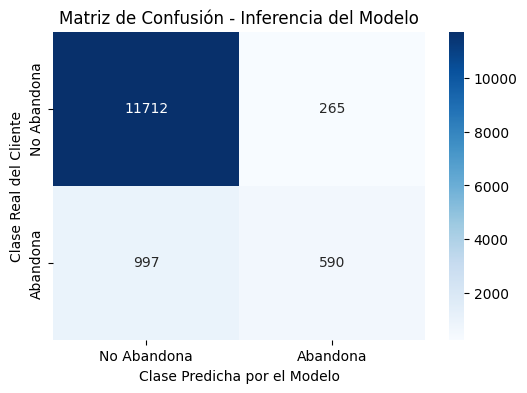

In [ ]:
# 1. Predicción o inferencia en el conjunto de prueba
y_pred = best_rf_model.predict(X_test)

# 2. Obtención de parámetros de evaluación del modelo
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=========================================")
print("  EVALUACIÓN DEL MODELO FINAL OPTIMIZADO")
print("=========================================")
print(f"Exactitud (Accuracy):  {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"F1-Score:              {f1:.4f}")
print("=========================================\n")

print("Reporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred))

# Graficar la Matriz de Confusión para validar errores de tipo I y tipo II
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Abandona', 'Abandona'], yticklabels=['No Abandona', 'Abandona'])
plt.title('Matriz de Confusión - Inferencia del Modelo')
plt.ylabel('Clase Real del Cliente')
plt.xlabel('Clase Predicha por el Modelo')
plt.show()

# **VISUALIZACIÓN DEL NEGOCIO**

/tmp/ipykernel_3599/1650428686.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=importances_top, y=features_top, palette='magma')


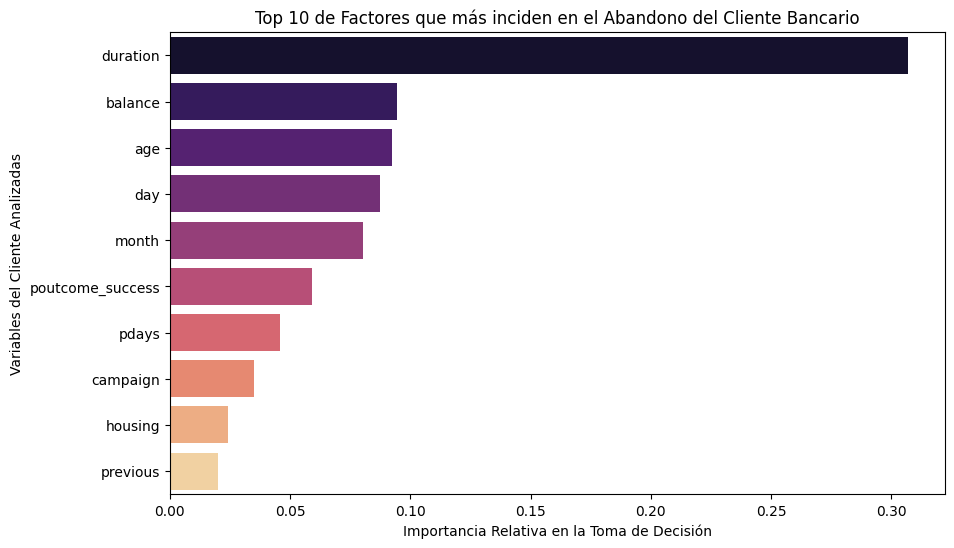

In [ ]:
# Extraer la importancia de las variables predictores
importances = best_rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Tomar los 10 factores más críticos del cliente
top_k = 10
features_top = [X.columns[i] for i in indices[:top_k]]
importances_top = importances[indices[:top_k]]

# Graficar el ranking de variables
plt.figure(figsize=(10,6))
sb.barplot(x=importances_top, y=features_top, palette='magma')
plt.title('Top 10 de Factores que más inciden en el Abandono del Cliente Bancario')
plt.xlabel('Importancia Relativa en la Toma de Decisión')
plt.ylabel('Variables del Cliente Analizadas')
plt.show()

# **CONCLUSIONES**
## Modelo de Abandono Financiero

**Factores Críticos de Incidencia:** La gráfica de importancia de variables demuestra que características operativas como la **duración de la última llamada (duration)**, el comportamiento temporal (**month** y **day**) y el balance financiero de la cuenta (**balance**) son los predictores con mayor peso para determinar si un usuario abandonará la entidad. Esto indica que la deserción está fuertemente ligada al nivel de contacto reciente y a la liquidez del cliente.

**Estrategia ante el Desbalance de Clientes:** Durante el Análisis Exploratorio de Datos (EDA) se identificó un desbalance severo de clases (aproximadamente un 88% de clientes retenidos frente a un 12% de desertores). Si hubiéramos evaluado el modelo solo por Exactitud (Accuracy), el negocio correría el riesgo de ignorar a los usuarios en riesgo. Por ello, la optimización mediante la métrica **F1-Score** en el *Parameter Tuning* fue la decisión correcta para equilibrar el modelo.

**Valor del Modelo para el Área de Crédito y Riesgo:** El algoritmo entrenado (Random Forest) demostró ser el más adecuado por su capacidad para procesar múltiples variables categóricas de manera limpia y sin sobreajuste. Para el banco, este modelo tiene un valor preventivo: permite activar alertas tempranas sobre clientes con alta probabilidad de abandono, facilitando al equipo de fidelización el diseño de campañas de retención oportunas antes de perder la relación comercial y la colocación de créditos.
